In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(1)

## Данные: XOR

Синтетические данные: 200 точек в квадрате [−1, 1]². Класс 0, если x1·x2 < 0, иначе класс 1 — задача линейно неразделимая (XOR). Сплит 100/100 на train/valid.

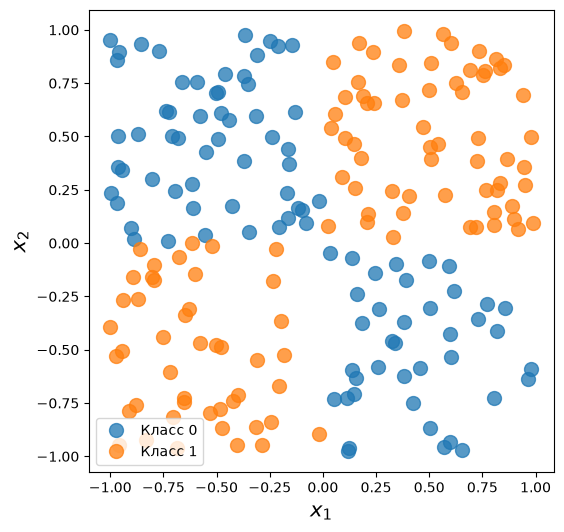

In [2]:
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1] < 0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], x[y==0, 1], 'o', alpha=0.75, markersize=10, label='Класс 0')
plt.plot(x[y==1, 0], x[y==1, 1], 'o', alpha=0.75, markersize=10, label='Класс 1')
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.legend()
plt.show()

## Архитектура, loss и оптимизатор

MLP: Linear(2→4) → ReLU → Linear(4→4) → ReLU → Linear(4→1) → Sigmoid. Бинарная классификация → `BCELoss`, SGD (lr=0.015).

In [3]:
from torch import nn
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

## Загрузка данных

`TensorDataset` связывает признаки и метки; `DataLoader` выдаёт батчи по 2 с перемешиванием.

In [4]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(x_train, y_train)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

## Цикл обучения

Функция `train` гоняет эпохи: на батч — forward → loss → backward → step → zero_grad. Считает loss и accuracy (по порогу 0.5) для train и valid (на валидации без backward).

In [5]:
def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_list_train = [0] * num_epochs
    accuracy_list_train = [0] * num_epochs
    loss_list_valid = [0] * num_epochs
    accuracy_list_valid = [0] * num_epochs
    
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            loss_list_train[epoch] += loss.item()
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_list_train[epoch] += is_correct.mean()
        
        loss_list_train[epoch] /= n_train / batch_size
        accuracy_list_train[epoch] /= n_train / batch_size
        
        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_list_valid[epoch] += loss.item()
        is_correct = ((pred >= 0.5).float() == y_valid).float()
        accuracy_list_valid[epoch] += is_correct.mean()
    
    return loss_list_train, loss_list_valid, accuracy_list_train, accuracy_list_valid

In [6]:
num_epochs = 200
history = train(model, num_epochs, train_dl, x_valid, y_valid)

## Обучение

Запускаем обучение на 200 эпох; история сохраняется для графиков.

## Результаты

Графики: слева loss (train/valid), справа accuracy. Близость кривых train и valid — переобучения почти нет.

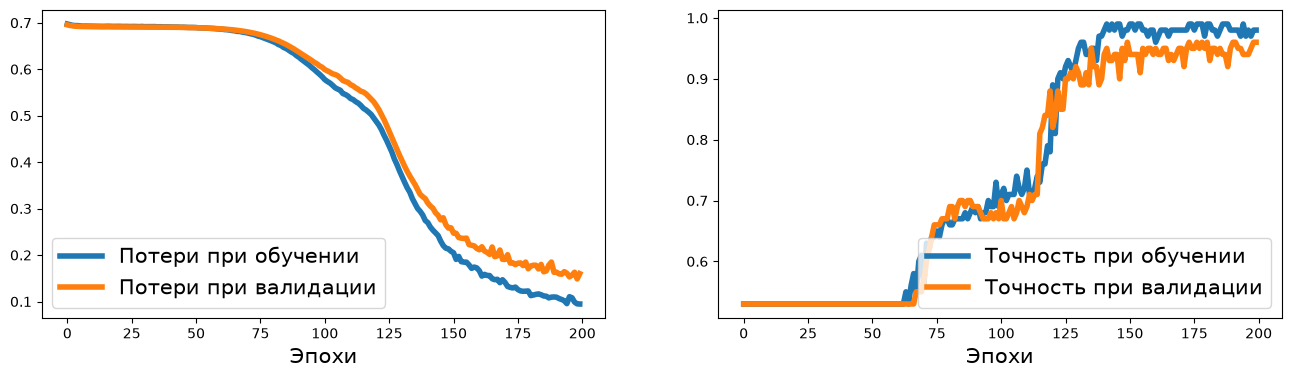

In [7]:
fig = plt.figure(figsize=(16, 4))

ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Потери при обучении', 'Потери при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Точность при обучении', 'Точность при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)

plt.show()

Альтернативное создание модели через nn.Module

## Модель через nn.Module

Тот же MLP, но как класс: слои собраны в `nn.ModuleList`, который регистрирует их как параметры модели. `forward` прогоняет вход через каждый слой по цепочке.

In [8]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x